In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df= pd.read_csv(r'C:\Users\ABL\Desktop\task7-Time Series Breakdown of Retail Sales\train.csv')
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


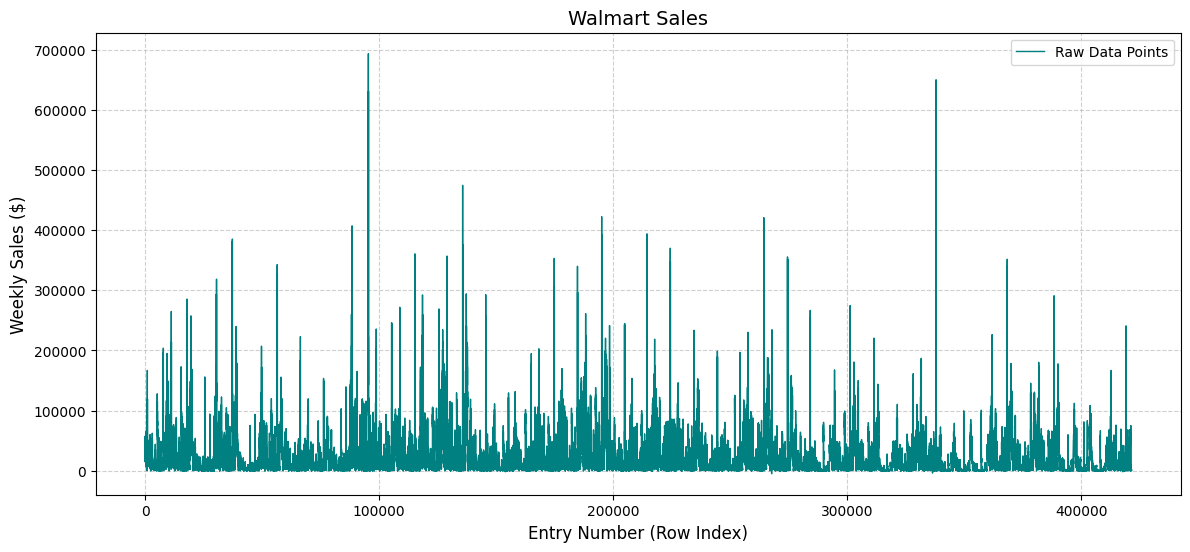

In [3]:
# 2. Plotting the raw "Weekly_Sales" in the order they appear
plt.figure(figsize=(14, 6))
plt.plot(df['Weekly_Sales'], color='teal', linewidth=1, label='Raw Data Points')

# Adding labels and context
plt.title('Walmart Sales', fontsize=14)
plt.xlabel('Entry Number (Row Index)', fontsize=12)
plt.ylabel('Weekly Sales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

In [4]:
df.dtypes

Store             int64
Dept              int64
Date             object
Weekly_Sales    float64
IsHoliday          bool
dtype: object

In [5]:
#1. Convert Date to datetime objects
df['Date'] = pd.to_datetime(df['Date'])


**retail dataset with monthly sales**

In [6]:
# 2. Set Date as the index
df.set_index('Date', inplace=True)

# 3. Resample to Month-Start ('MS') and Sum the sales
monthly_sales = df['Weekly_Sales'].resample('MS').sum().to_frame()


In [7]:
print(monthly_sales.head())

            Weekly_Sales
Date                    
2010-02-01  1.903330e+08
2010-03-01  1.819198e+08
2010-04-01  2.314124e+08
2010-05-01  1.867109e+08
2010-06-01  1.922462e+08


**Plotting Trends & Moving Averages**

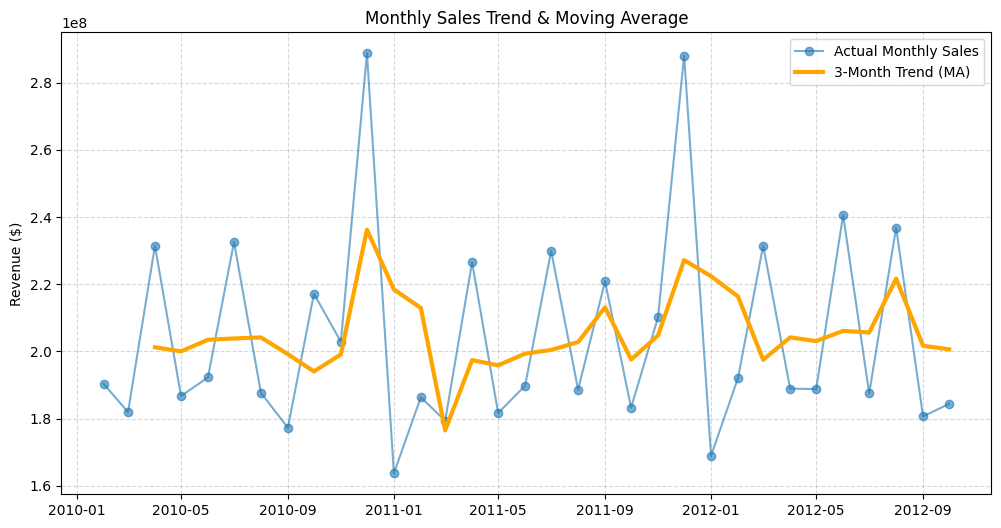

In [8]:
# Calculate 3-Month Moving Average:
monthly_sales['Rolling_Avg'] = monthly_sales['Weekly_Sales'].rolling(window=3).mean()

plt.figure(figsize=(12,6))
plt.plot(monthly_sales.index, monthly_sales['Weekly_Sales'], label='Actual Monthly Sales', marker='o', alpha=0.6)
plt.plot(monthly_sales.index, monthly_sales['Rolling_Avg'], label='3-Month Trend (MA)', color='orange', linewidth=3)

plt.title('Monthly Sales Trend & Moving Average')
plt.ylabel('Revenue ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

**Seasonal patterns**

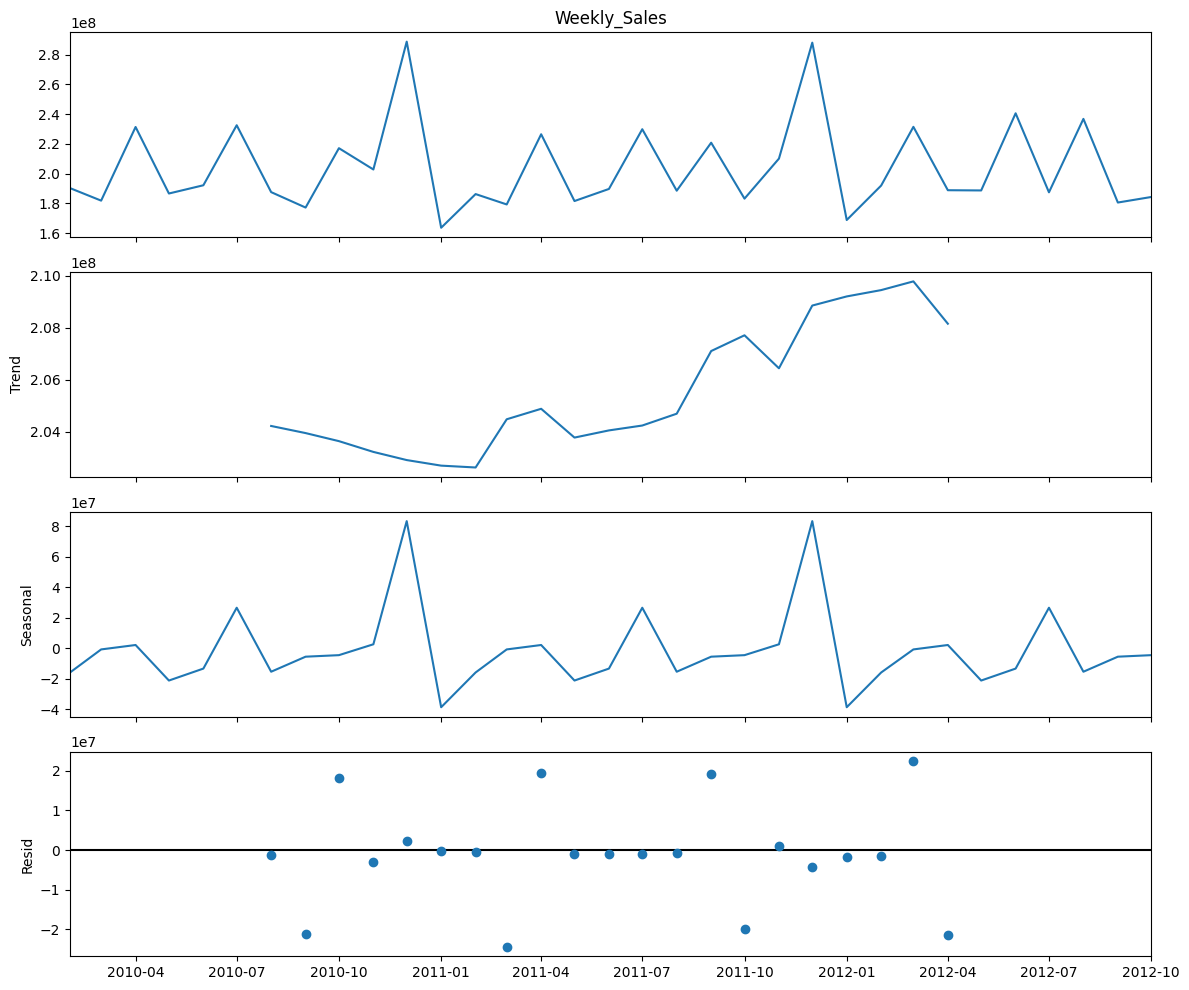

In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose the data assuming a 12-month cycle , So Period=12 because we are looking at monthly data
decomposition = seasonal_decompose(monthly_sales['Weekly_Sales'], model='additive', period=12)

# Plot the components
fig = decomposition.plot()
fig.set_size_inches(12, 10)
plt.tight_layout()
plt.show()

**Notes**\
**trend:** After removing seasonal noise, we see a strong upward trend starting in early 2011 , and he business is fundamentally larger in 2012 than it was in 2010.\
**seasonal:** The store follows a highly predictable annual cycle , The pattern from 2010 to 2011 is almost identical to 2011 to 2012 , we can say thet the customers have very consistent habits. \
**resid:** The residuals are mostly stable, but there are a few outliers (dots far from the zero line)



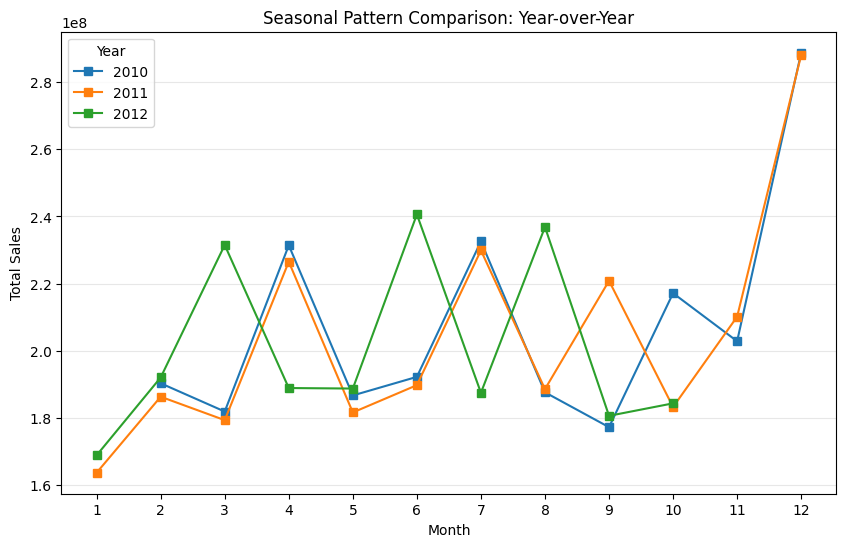

In [ ]:
# Create columns for Year and Month
monthly_sales['Year'] = monthly_sales.index.year
monthly_sales['Month'] = monthly_sales.index.month

# Pivot to get Months as X-axis and Years as separate lines
seasonal_pivot = monthly_sales.pivot(index='Month', columns='Year', values='Weekly_Sales')

seasonal_pivot.plot(figsize=(10, 6), marker='s')
plt.title('Seasonal Pattern Comparison: Year-over-Year')
plt.xticks(range(1, 13)) 
plt.ylabel('Total Sales')
plt.grid(axis='y', alpha=0.3)
plt.show()

**Note**
- Every single year, as soon as December arrives, the sales for every year jump up to a massive peak.
- This proves that the business is heavily dependent on the Christmas/Holiday season for annual profitability.
- The tight correlation between the 2010 and 2011 cycles indicates a very stable and predictable consumer purchasing pattern
- the Green line (2012) is higher than the others because the business is growing. But in April (Month 4), the Blue line (2010) suddenly jumps above everyone else.
- In April, it is "weird" that the oldest year (2010) beat the newest year (2012).
- Maybe in April 2010, the store had a huge "Grand Opening" sale that they didn't do again in 2011.

# Breakdown by Product Over Time and Region Over Time

**Dept represents the product category and Store represents the region.**

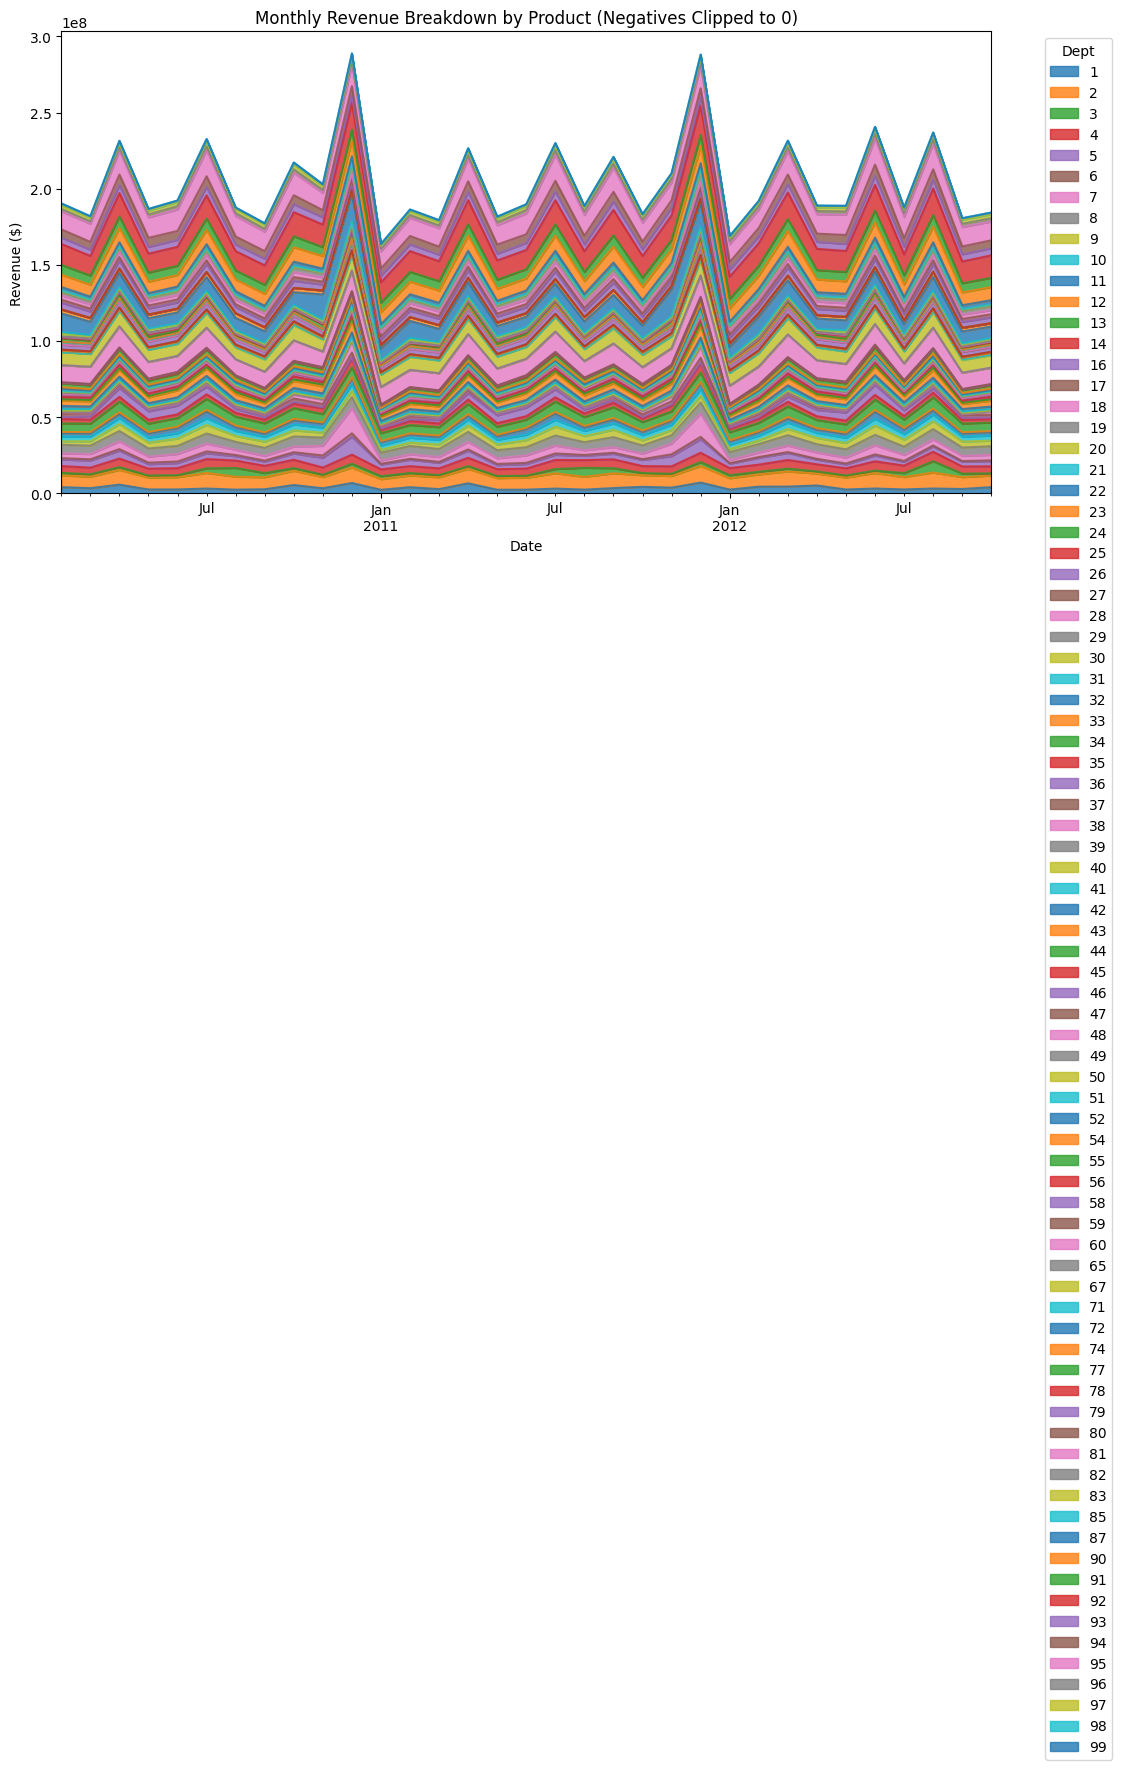

In [ ]:
#1-Breakdown by Product (Department) Over Time:

# 1.1. Pivot and Resample 
product_breakdown = df.pivot_table(index='Date', columns='Dept', values='Weekly_Sales', aggfunc='sum')
monthly_product = product_breakdown.resample('MS').sum()

# 1.2. FIX: Clip negative values to 0   , When stacked is True, each column must be either all positive or all negative.
# This replaces any negative number with 0 so the 'Stack' doesn't break.
monthly_product_clipped = monthly_product.clip(lower=0)

# 1.3. Plot the clipped data
monthly_product_clipped.plot(kind='area', stacked=True, figsize=(12, 6), alpha=0.8)

plt.title('Monthly Revenue Breakdown by Product (Negatives Clipped to 0)')
plt.ylabel('Revenue ($)')
plt.legend(title='Dept', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

**Note**
- The overall shape of the chart shows that our total revenue follows a very consistent 'wave' pattern every year.
- Certain departments, like the ones in the middle and bottom layers, are much thicker than others.
- The peaks are synchronized across all departments, particularly during the end-of-year holiday surge.

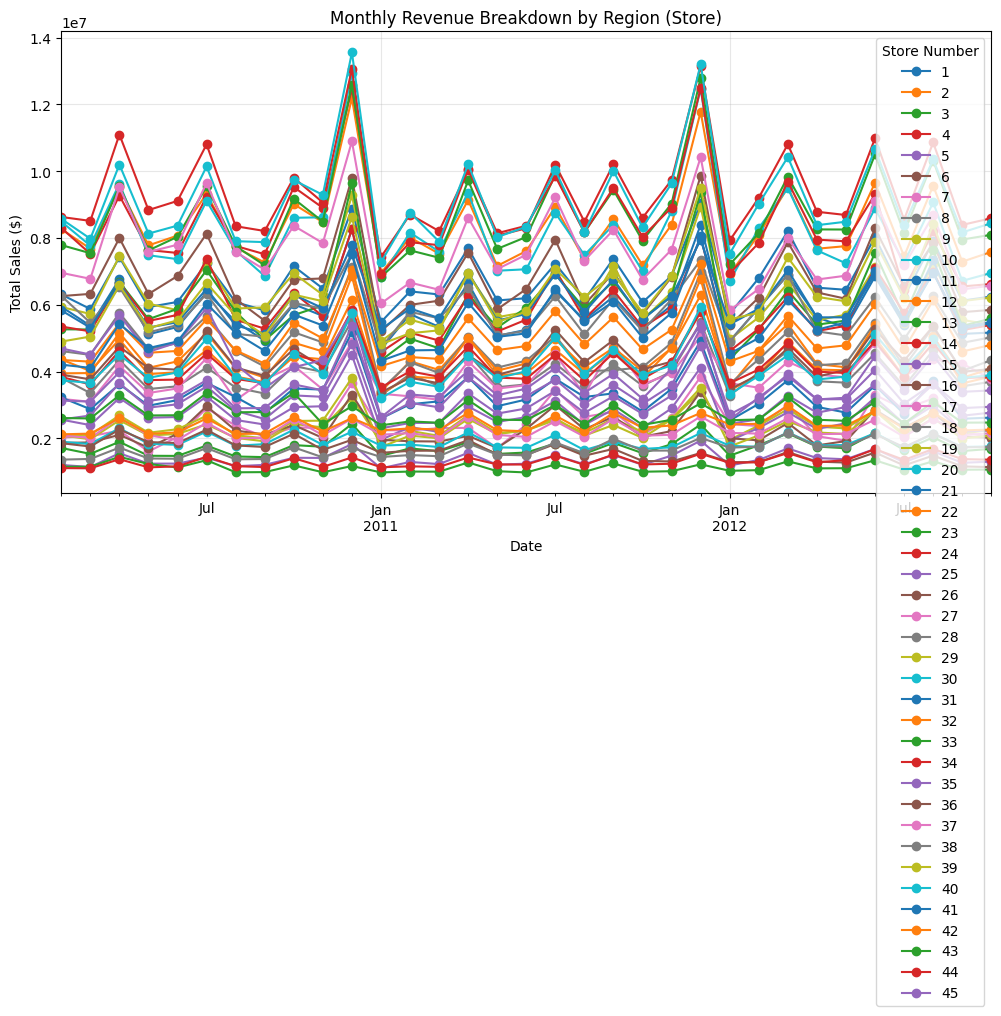

In [13]:
#2-Breakdown by Region (Store) Over Time
# 2.1. Pivot the data: Index is Date, Columns are Store (Region)
region_breakdown = df.pivot_table(index='Date', columns='Store', values='Weekly_Sales', aggfunc='sum')

# 2.2. Resample to Monthly
monthly_region = region_breakdown.resample('MS').sum()

# 2.3. Plot as a Line Chart to compare regional growth rates
monthly_region.plot(kind='line', figsize=(12, 6), marker='o')

plt.title('Monthly Revenue Breakdown by Region (Store)')
plt.ylabel('Total Sales ($)')
plt.legend(title='Store Number')
plt.grid(True, alpha=0.3)
plt.show()

# exponential smoothing : Holt-Winters

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# 1. Set the frequency of the index (Monthly Start)
monthly_sales.index.freq = 'MS'

# 2. Fit the Exponential Smoothing model
# here 'add' means the seasonal fluctuations are roughly the same size each year
model = ExponentialSmoothing(
    monthly_sales['Weekly_Sales'], 
    trend='add', 
    seasonal='add', 
    seasonal_periods=12
).fit()

# 3. Forecast for the next 6 months (exemple)
forecast = model.forecast(6)



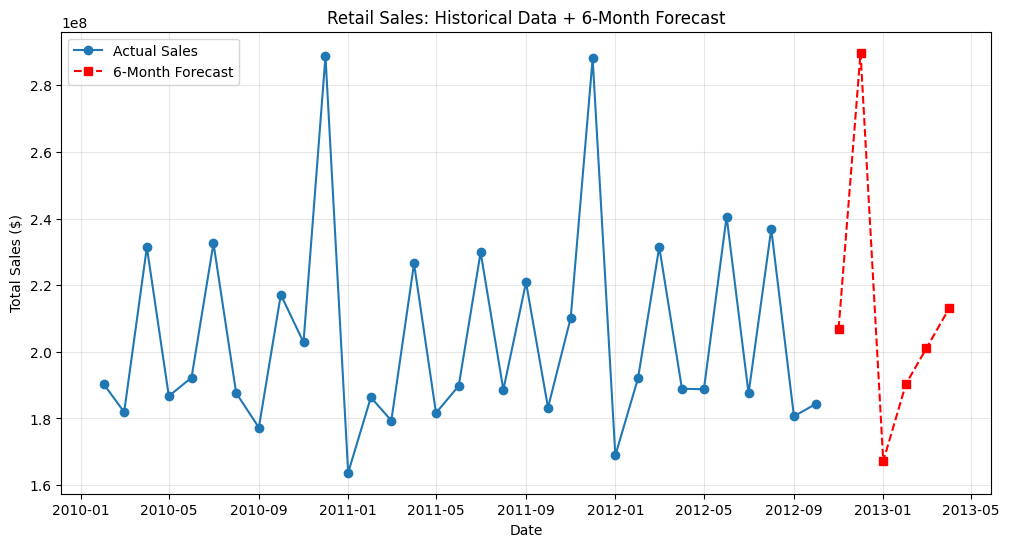

In [ ]:
# 4.Plotting History vs. The Future
plt.figure(figsize=(12, 6))

# Plot historical data
plt.plot(monthly_sales.index, monthly_sales['Weekly_Sales'], label='Actual Sales', marker='o')

# Plot the forecast
plt.plot(forecast.index, forecast, label='6-Month Forecast', color='red', linestyle='--', marker='s')

plt.title('Retail Sales: Historical Data + 6-Month Forecast')
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()